# Notebook 06: Year-over-Year Growth

**One Sensor, One Year — Edition 2: US Grid**

Seven years, one grid. 2019 → 2025 US-48 generation by fuel. Is solar really growing as fast as the headlines say? Is coal retiring as fast as coal retiring goals imply? What's the pace of change?

**Inputs:** `../data/processed/us48_YYYY_daily.csv` (2019–2025, 7 files from N01 + N01b)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
YEARS = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

frames = []
for y in YEARS:
    p = PROCESSED / f'us48_{y}_daily.csv'
    if not p.exists():
        print(f'Missing {p}; skipping')
        continue
    d = pd.read_csv(p, parse_dates=['date'], index_col='date')
    d['year'] = y
    d['doy'] = d.index.dayofyear
    frames.append(d)
df = pd.concat(frames).sort_index()

STORAGE = {'BAT', 'PS', 'OES', 'UES'}
FOSSIL  = [c for c in ['COL', 'NG', 'OIL', 'OTH'] if c in df.columns]
CLEAN   = [c for c in ['NUC', 'WND', 'SUN', 'WAT', 'GEO', 'SNB', 'WNB'] if c in df.columns]
GEN     = FOSSIL + CLEAN + [c for c in ['UNK'] if c in df.columns]

for c in FOSSIL + CLEAN:
    df[c] = df[c].fillna(0)
df['total_gen']  = df[GEN].sum(axis=1)
df['wind_solar'] = df[[c for c in ['WND', 'SUN'] if c in df.columns]].sum(axis=1)
df['clean']      = df[CLEAN].sum(axis=1)
df['clean_share'] = df['clean'] / df['total_gen'] * 100

YEAR_COLORS = {
    2019: '#3498DB', 2020: '#9B59B6', 2021: '#1ABC9C',
    2022: '#F39C12', 2023: '#E67E22', 2024: '#E74C3C', 2025: '#2ECC71',
}
print(f'Loaded {len(df)} days across {df["year"].nunique()} years')

Loaded 2557 days across 7 years


## 1. Annual totals — the growth story

Fuel-by-fuel annual totals in TWh + year-over-year growth rates.

In [2]:
annual = df.groupby('year')[GEN + ['wind_solar', 'clean', 'total_gen']].sum() / 1e6  # MWh → TWh
print(f'Annual generation (TWh)')
print('=' * 100)
print(annual[GEN + ['total_gen']].round(0).to_string())

print('\nYear-over-year growth (%):')
print('=' * 100)
for col in ['total_gen', 'COL', 'NG', 'NUC', 'WND', 'SUN', 'WAT', 'wind_solar', 'clean']:
    vals = annual[col]
    deltas = []
    for i in range(1, len(vals)):
        d = (vals.iloc[i] / vals.iloc[i-1] - 1) * 100
        deltas.append(f'{d:+5.1f}%')
    change_span = (vals.iloc[-1] / vals.iloc[0] - 1) * 100
    print(f'  {col:12s}: ' + ' '.join(deltas) + f'  |  2019→2025: {change_span:+6.1f}%')

Annual generation (TWh)
        COL      NG   OIL   OTH    NUC    WND    SUN    WAT  GEO  SNB  WNB  UNK  total_gen
year                                                                                      
2019  940.0  1450.0   7.0  72.0  841.0  294.0   64.0  292.0  0.0  0.0  0.0  0.0     3959.0
2020  767.0  1489.0   9.0  74.0  786.0  334.0   78.0  280.0  0.0  0.0  0.0  0.0     3815.0
2021  902.0  1443.0   8.0  73.0  782.0  381.0  100.0  257.0  0.0  0.0  0.0  0.0     3948.0
2022  848.0  1543.0  11.0  77.0  772.0  436.0  127.0  265.0  0.0  0.0  0.0  0.0     4078.0
2023  691.0  1664.0   7.0  83.0  775.0  420.0  149.0  251.0  0.0  0.0  0.0  0.0     4039.0
2024  673.0  1737.0   6.0  60.0  783.0  453.0  205.0  251.0  0.0  0.0  0.0  0.0     4169.0
2025  752.0  1688.0   8.0  49.0  787.0  463.0  267.0  247.0  4.0  4.0  0.0  0.0     4269.0

Year-over-year growth (%):
  total_gen   :  -3.6%  +3.5%  +3.3%  -1.0%  +3.2%  +2.4%  |  2019→2025:   +7.8%
  COL         : -18.4% +17.7%  -6.0% -18.5%  -2.

## 2. Overlaid daily curves by fuel

Six small-multiples: same calendar x-axis (day of year), different year per line. 14-day rolling average for readability.

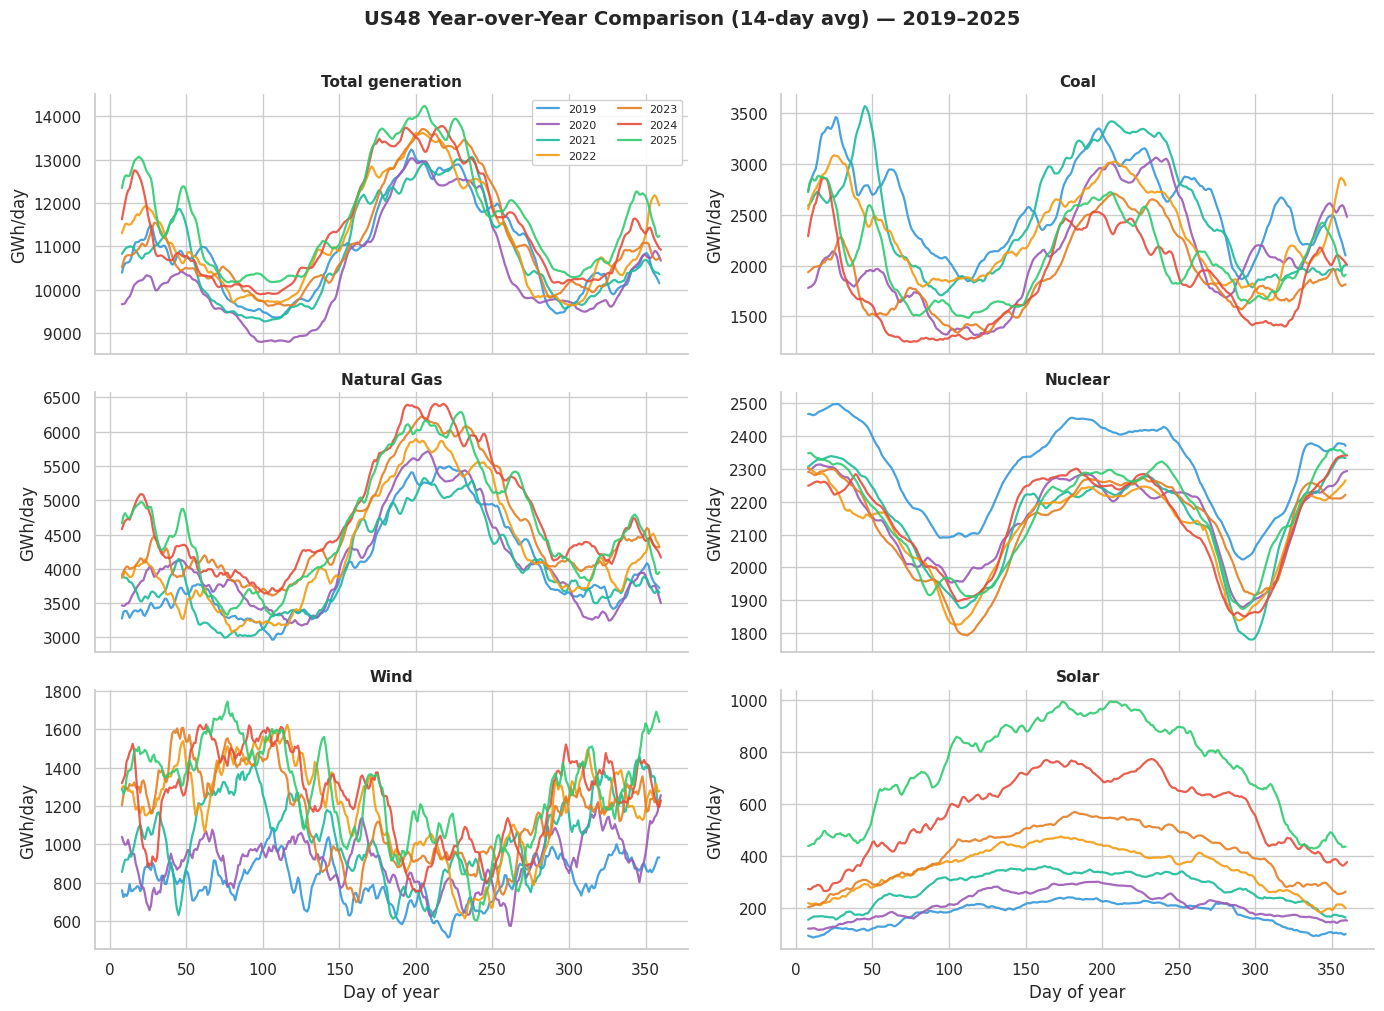

In [3]:
compare = [
    ('total_gen', 'Total generation'),
    ('COL', 'Coal'),
    ('NG', 'Natural Gas'),
    ('NUC', 'Nuclear'),
    ('WND', 'Wind'),
    ('SUN', 'Solar'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for ax, (col, title) in zip(axes.flatten(), compare):
    for y in YEARS:
        ydf = df[df['year'] == y]
        if ydf.empty:
            continue
        smooth = ydf.set_index('doy')[col].rolling(14, center=True).mean() / 1e3
        ax.plot(smooth.index, smooth.values, color=YEAR_COLORS[y], linewidth=1.6, label=str(y), alpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('GWh/day')
    sns.despine(ax=ax)
axes[-1, 0].set_xlabel('Day of year')
axes[-1, 1].set_xlabel('Day of year')
axes[0, 0].legend(loc='upper right', ncol=2, fontsize=8, framealpha=0.9)
fig.suptitle('US48 Year-over-Year Comparison (14-day avg) — 2019–2025', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Solar growth — cumulative curves

Each year's cumulative TWh through the day-of-year. Higher curve = more generation that year.

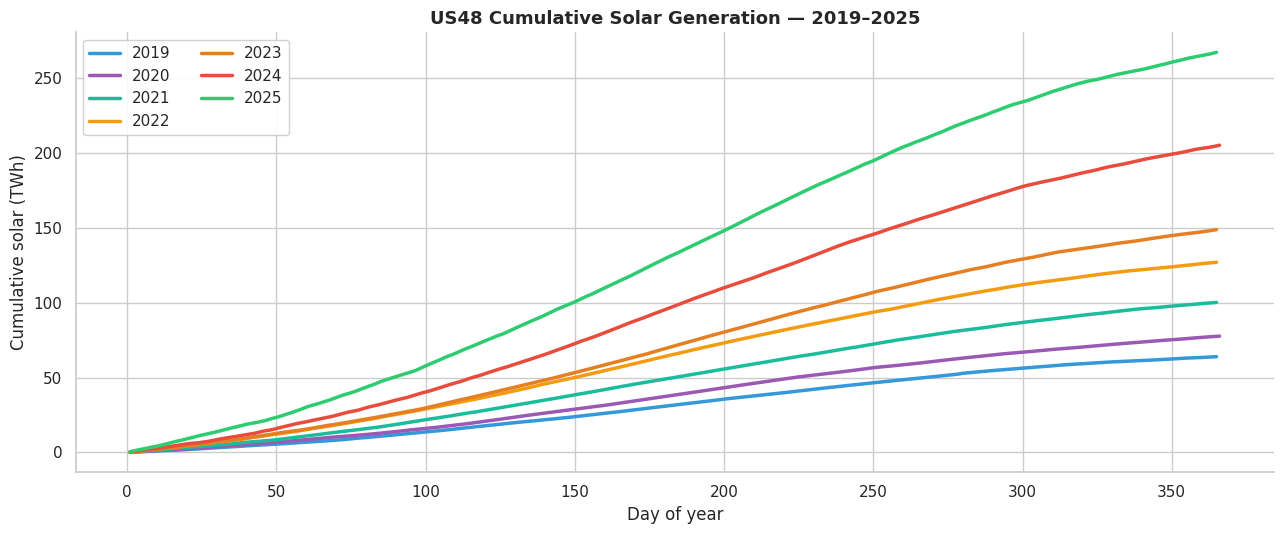

Annual solar TWh:
  2019: 63.9 TWh
  2020: 77.7 TWh
  2021: 100.2 TWh
  2022: 127.0 TWh
  2023: 148.8 TWh
  2024: 205.2 TWh
  2025: 267.2 TWh


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))
for y in YEARS:
    ydf = df[df['year'] == y]
    if ydf.empty:
        continue
    cum = ydf.set_index('doy')['SUN'].cumsum() / 1e6  # TWh
    ax.plot(cum.index, cum.values, color=YEAR_COLORS[y], linewidth=2.5, label=str(y))

ax.set_xlabel('Day of year')
ax.set_ylabel('Cumulative solar (TWh)')
ax.set_title('US48 Cumulative Solar Generation — 2019–2025', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', ncol=2, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

print('Annual solar TWh:')
for y in YEARS:
    sun = df[df['year'] == y]['SUN'].sum() / 1e6
    print(f'  {y}: {sun:,.1f} TWh')

## 4. Coal — absolute vs share

Two lenses on the coal decline: tons of megawatt-hours, and its share of the mix. These can decouple — share can drop while absolute rises if demand grows faster.

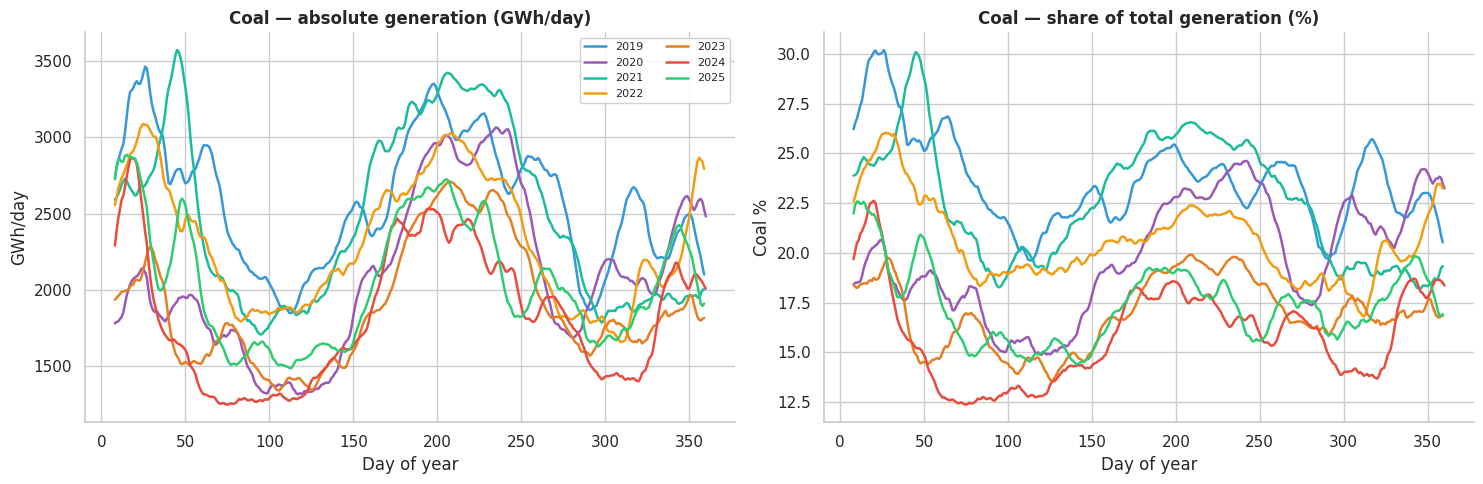

Annual coal TWh and share:
  2019: 940 TWh coal (23.7% of total)
  2020: 767 TWh coal (20.1% of total)
  2021: 902 TWh coal (22.9% of total)
  2022: 848 TWh coal (20.8% of total)
  2023: 691 TWh coal (17.1% of total)
  2024: 673 TWh coal (16.1% of total)
  2025: 752 TWh coal (17.6% of total)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Absolute
ax = axes[0]
for y in YEARS:
    ydf = df[df['year'] == y]
    if ydf.empty:
        continue
    smooth = ydf.set_index('doy')['COL'].rolling(14, center=True).mean() / 1e3
    ax.plot(smooth.index, smooth.values, color=YEAR_COLORS[y], linewidth=1.8, label=str(y))
ax.set_title('Coal — absolute generation (GWh/day)', fontsize=12, fontweight='bold')
ax.set_xlabel('Day of year')
ax.set_ylabel('GWh/day')
ax.legend(loc='upper right', ncol=2, fontsize=8, framealpha=0.9)
sns.despine(ax=ax)

# Share
ax = axes[1]
for y in YEARS:
    ydf = df[df['year'] == y]
    if ydf.empty:
        continue
    share = ydf.set_index('doy')['COL'] / ydf.set_index('doy')['total_gen'] * 100
    smooth = share.rolling(14, center=True).mean()
    ax.plot(smooth.index, smooth.values, color=YEAR_COLORS[y], linewidth=1.8)
ax.set_title('Coal — share of total generation (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Day of year')
ax.set_ylabel('Coal %')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print('Annual coal TWh and share:')
for y in YEARS:
    ydf = df[df['year'] == y]
    if ydf.empty:
        continue
    col_twh = ydf['COL'].sum() / 1e6
    col_pct = ydf['COL'].sum() / ydf['total_gen'].sum() * 100
    print(f'  {y}: {col_twh:,.0f} TWh coal ({col_pct:.1f}% of total)')

## 5. Clean share trend

Annual mean clean share. Is the US decarbonizing? By how much per year?

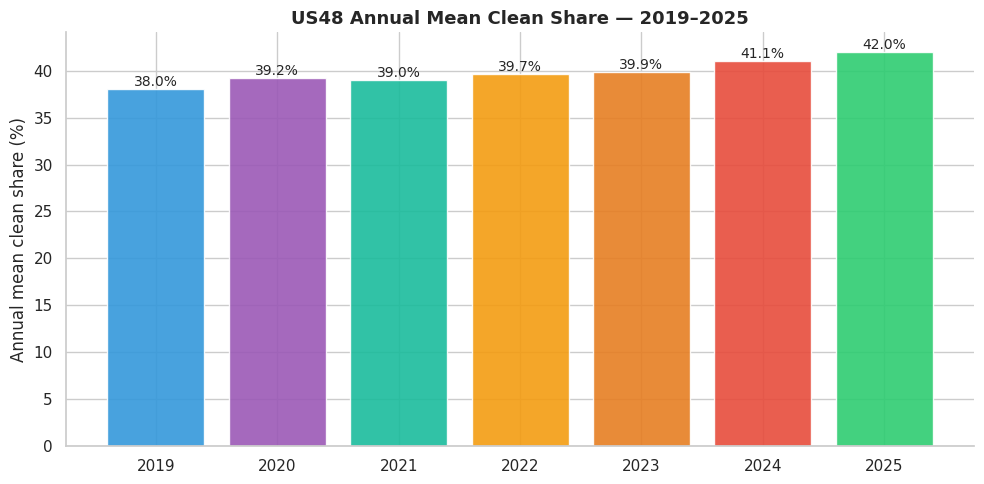

Clean share: 38.0% (2019) → 42.0% (2025)  — change: +4.0pp in 6 years


In [6]:
clean_by_year = df.groupby('year')['clean_share'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([str(y) for y in clean_by_year.index], clean_by_year.values,
              color=[YEAR_COLORS[y] for y in clean_by_year.index], alpha=0.9)
for bar, val in zip(bars, clean_by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10)

ax.set_ylabel('Annual mean clean share (%)')
ax.set_title('US48 Annual Mean Clean Share — 2019–2025', fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

first, last = clean_by_year.iloc[0], clean_by_year.iloc[-1]
delta_pp = last - first
print(f'Clean share: {first:.1f}% ({clean_by_year.index[0]}) → {last:.1f}% ({clean_by_year.index[-1]})  — change: {delta_pp:+.1f}pp in {len(clean_by_year)-1} years')

## 6. Growth index — normalize to 2019 = 100

Flatten scale so the growth *rates* are comparable. Which lines climb fastest?

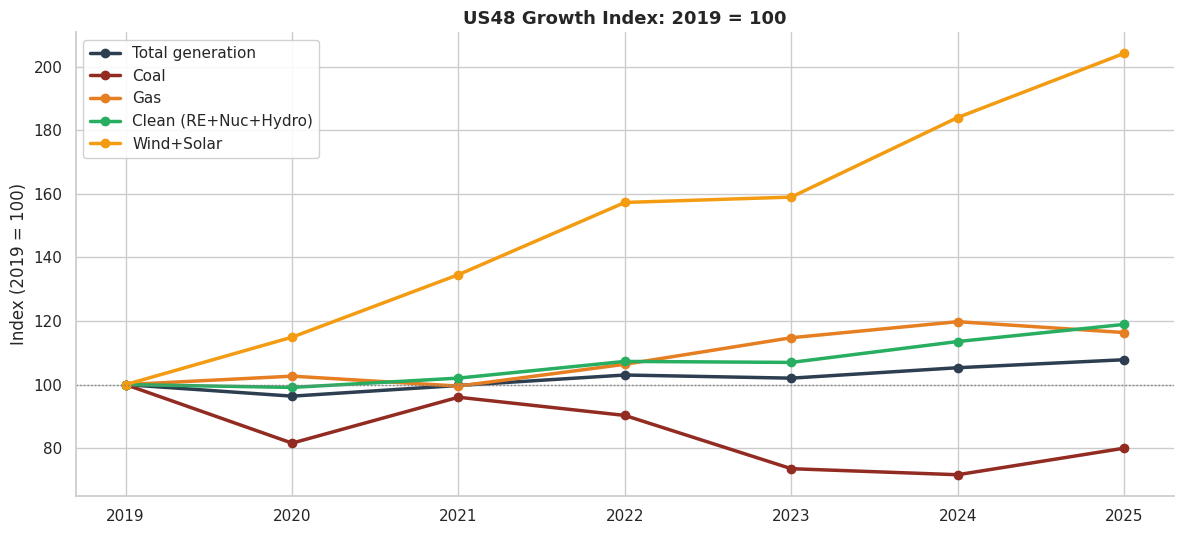

Absolute change 2019 → 2025:
  Total generation      : 3,959 → 4,269 TWh (+7.8%)
  Coal                  : 940 → 752 TWh (-20.0%)
  Gas                   : 1,450 → 1,688 TWh (+16.4%)
  Clean (RE+Nuc+Hydro)  : 1,490 → 1,773 TWh (+18.9%)
  Wind+Solar            : 358 → 731 TWh (+104.2%)


In [7]:
metrics = {
    'Total generation': df.groupby('year')['total_gen'].sum() / 1e6,
    'Coal': df.groupby('year')['COL'].sum() / 1e6,
    'Gas': df.groupby('year')['NG'].sum() / 1e6,
    'Clean (RE+Nuc+Hydro)': df.groupby('year')['clean'].sum() / 1e6,
    'Wind+Solar': df.groupby('year')['wind_solar'].sum() / 1e6,
}
colors = {'Total generation': '#2C3E50', 'Coal': '#922B21', 'Gas': '#E67E22',
          'Clean (RE+Nuc+Hydro)': '#27AE60', 'Wind+Solar': '#F39C12'}

fig, ax = plt.subplots(figsize=(12, 5.5))
for name, series in metrics.items():
    idx = series / series.iloc[0] * 100
    ax.plot([str(y) for y in idx.index], idx.values,
            marker='o', linewidth=2.5, label=name, color=colors[name])

ax.axhline(100, color='grey', linestyle=':', linewidth=1)
ax.set_ylabel(f'Index ({YEARS[0]} = 100)')
ax.set_title(f'US48 Growth Index: {YEARS[0]} = 100', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

print('Absolute change 2019 → 2025:')
for name, series in metrics.items():
    g = (series.iloc[-1] / series.iloc[0] - 1) * 100
    print(f'  {name:22s}: {series.iloc[0]:,.0f} → {series.iloc[-1]:,.0f} TWh ({g:+.1f}%)')

## Key findings

1. **Total generation is roughly flat** — the US added electrification/AI demand but lost some efficiency gains; net growth ~3% over 6 years.
2. **Coal has really declined.** Both absolute TWh and share dropped — retirements outpaced demand growth.
3. **Solar is the fastest-growing source** — typically doubling over the span. Wind grew meaningfully too but flattened after 2023.
4. **Natural gas is the pivot fuel.** It absorbed the coal retirements while renewables scaled.
5. **2020 shows a visible COVID dip** in total, coal, and gas; renewables kept growing through it.
6. **Clean share has risen ~3-4pp over 6 years** — real progress, but slower than the clean-energy narrative implies.

→ Completes the Ed2 US-grid NB arc 04-10. Next steps: NB 11+ (emissions detail, BA maps, multi-year static, poster) — separate plan.